# ACGCN Multi-Omics Node Classification

## Configuration

In [ ]:
import argparse
import torch
from src.train import train, plot_and_analyze, save_predicted_scores, process_predictions, generate_kde_and_curves, load_gene_set, save_predictions_to_csv, save_confirmed_predictions_to_csv, save_predicted_known_drivers
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import os

from sklearn.metrics import precision_recall_curve, auc


def get_args():
    parser = argparse.ArgumentParser(description="GNN-based Driver Gene Prediction")
    parser.add_argument('--in_feats', type=int, default=2048)
    parser.add_argument('--hidden_feats', type=int, default=1024)
    parser.add_argument('--out_feats', type=int, default=1)
    parser.add_argument('--learning_rate', type=float, default=1e-3)
    parser.add_argument('--num_epochs', type=int, default=100)
    parser.add_argument('--model_type', type=str,
                        choices=['GraphSAGE','GAT','GCN','GIN','Chebnet','HGDC','EMOGI','MTGCN','ACGNN'],
                        required=True)
    parser.add_argument('--net_type', type=str,
                        choices=['CPDB','STRING','HIPPIE'],
                        required=False)
    parser.add_argument('--device', type=str,
                        default='cuda' if torch.cuda.is_available() else 'cpu')
    parser.add_argument('--score_threshold', type=float, default=0.99)
    return parser.parse_args()

args = get_args = argparse.Namespace(
    in_feats=2048,
    hidden_feats=128,
    out_feats=1,
    learning_rate=1e-3,
    num_epochs=50,
    model_type="ACGNN",
    net_type="STRING",
    device="cuda" if torch.cuda.is_available() else "cpu",
    score_threshold=0.99
)

args



Namespace(in_feats=2048, hidden_feats=128, out_feats=1, learning_rate=0.001, num_epochs=50, model_type='ACGNN', net_type='HIPPIE', device='cpu', score_threshold=0.99)

## Graph Construction from Multi-Omics Embeddings

In [246]:

import os
import dgl
import torch
from src.data_loader import load_data
import json
from src.utils import (choose_model, plot_roc_curve, plot_pr_curve, load_graph_data, 
                       load_oncokb_genes, plot_and_analyze, save_and_plot_results)

# data_path = os.path.join('../ACGNN_data/data/multiomics_meth/', f'{args.net_type}_omics_ppi_embeddings_graph_2048_gene_pathway.json')

data_path = os.path.join('../gat/data/multiomics_meth/', f'{args.net_type}_omics_ppi_embeddings_graph_2048.json')
nodes, edges, embeddings, labels = load_graph_data(data_path)

graph = dgl.graph(edges)
graph.ndata['feat'] = embeddings
graph.ndata['label'] = labels
graph.ndata['train_mask'] = labels != -1
graph.ndata['test_mask'] = torch.ones_like(labels, dtype=torch.bool)

graph = dgl.add_self_loop(graph)

print(graph)



Graph(num_nodes=1978, num_edges=19688,
      ndata_schemes={'feat': Scheme(shape=(2048,), dtype=torch.float32), 'label': Scheme(shape=(), dtype=torch.int64), 'train_mask': Scheme(shape=(), dtype=torch.bool), 'test_mask': Scheme(shape=(), dtype=torch.bool)}
      edata_schemes={})


In [247]:
import os
import csv
import time
import psutil
import torch
import torch.nn as nn
import pandas as pd
import dgl
from tqdm import tqdm
from collections import defaultdict

RESULTS_DIR = "results/gene_prediction"
os.makedirs(RESULTS_DIR, exist_ok=True)


In [248]:
from src.models import ACGNN, FocalLoss
from src.utils import load_graph_data, choose_model

import os
import time
import psutil
import torch
import dgl
import numpy as np
from tqdm import tqdm


def train_return_objects(args):

    epoch_times, cpu_usages, gpu_usages = [], [], []

    # --------------------------------------------------
    # Load graph data
    # --------------------------------------------------
    data_path = os.path.join(
        "../gat/data/multiomics_meth/",
        f"{args.net_type}_omics_ppi_embeddings_graph_2048.json"
    )

    nodes, edges, embeddings, labels = load_graph_data(data_path)

    graph = dgl.graph(edges)
    graph = dgl.add_self_loop(graph)

    graph.ndata["feat"] = embeddings
    graph.ndata["label"] = labels
    graph.ndata["train_mask"] = labels != -1
    graph.ndata["test_mask"] = torch.ones_like(labels, dtype=torch.bool)

    device = torch.device(args.device)

    # --------------------------------------------------
    # Model
    # --------------------------------------------------
    model = choose_model(
        args.model_type,
        embeddings.shape[1],
        args.hidden_feats,
        1
    ).to(device)

    print("Model:", model)
    print("Model type:", args.model_type)

    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)
    loss_fn = FocalLoss(alpha=0.25, gamma=2)

    # --------------------------------------------------
    # Move tensors
    # --------------------------------------------------
    graph = graph.to(device)
    features = graph.ndata["feat"].to(device)
    labels = graph.ndata["label"].to(device).float()
    train_mask = graph.ndata["train_mask"].to(device)

    # --------------------------------------------------
    # Training loop
    # --------------------------------------------------
    for _ in tqdm(range(args.num_epochs), desc="Training"):
        t0 = time.time()

        cpu_usages.append(psutil.cpu_percent(interval=None))
        gpu_usages.append(
            torch.cuda.memory_allocated(device) / 1024**2
            if torch.cuda.is_available() else 0.0
        )

        model.train()
        logits = model(graph, features).squeeze()
        loss = loss_fn(logits[train_mask], labels[train_mask])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_times.append(time.time() - t0)

    # --------------------------------------------------
    # Final inference
    # --------------------------------------------------
    model.eval()
    with torch.no_grad():
        logits = model(graph, features).squeeze()
        scores = torch.sigmoid(logits).cpu().numpy()


    from collections import defaultdict

    # --------------------------------------------------
    # Degree counts (connections to GT driver genes)
    # --------------------------------------------------
    node_names = list(nodes.keys())

    # Ground-truth driver genes (label == 1)
    gt_driver_indices = [i for i, y in enumerate(labels.cpu()) if y == 1]
    gt_driver_names = {node_names[i] for i in gt_driver_indices}

    # Non-labeled nodes
    non_labeled_indices = [i for i, y in enumerate(labels.cpu()) if y == -1]

    # Threshold-based predictions
    predicted_above = {
        node_names[i]
        for i in non_labeled_indices
        if scores[i] >= args.score_threshold
    }
    predicted_below = {
        node_names[i]
        for i in non_labeled_indices
        if scores[i] < args.score_threshold
    }

    degree_counts_above = defaultdict(int)
    degree_counts_below = defaultdict(int)

    for src, dst in edges:
        src_name = node_names[src]
        dst_name = node_names[dst]

        if dst_name in gt_driver_names:
            if src_name in predicted_above:
                degree_counts_above[src_name] += 1
            elif src_name in predicted_below:
                degree_counts_below[src_name] += 1

    # --------------------------------------------------
    # Return EVERYTHING needed downstream
    # --------------------------------------------------
    return {
        "scores": scores,
        "logits": logits.detach().cpu(),
        "labels": labels.detach().cpu(),
        "train_mask": train_mask.detach().cpu(),
        "nodes": nodes,
        "edges": edges,
        "graph": graph,
        "features": features.detach().cpu(),
        "degree_counts_above": degree_counts_above,
        "degree_counts_below": degree_counts_below,
        "epoch_times": epoch_times,
        "cpu": cpu_usages,
        "gpu": gpu_usages,
        "model": model
    }

results = train_return_objects(args)

Model: ACGNN(
  (cheb1): ChebConv(
    (linear): Linear(in_features=6144, out_features=128, bias=True)
  )
  (cheb2): ChebConv(
    (linear): Linear(in_features=384, out_features=128, bias=True)
  )
  (cheb3): ChebConv(
    (linear): Linear(in_features=384, out_features=128, bias=True)
  )
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout_layer): Dropout(p=0.3, inplace=False)
)
Model type: ACGNN


Training: 100%|██████████| 50/50 [00:07<00:00,  6.96it/s]


In [249]:
def calculate_and_save_prediction_stats(non_labeled_nodes, labels, node_names, scores, args):
    """
    Calculate prediction statistics and save them to a CSV file.

    Parameters:
    - non_labeled_nodes: List of nodes without labels
    - labels: List of ground truth labels for the nodes
    - node_names: List of node names corresponding to the nodes
    - scores: List of predicted scores for the nodes
    - args: Arguments containing model and network type, score threshold, and number of epochs
    """
    # Calculate statistics
    non_labeled_nodes_count = len(non_labeled_nodes)
    ground_truth_driver_nodes = [i for i, label in enumerate(labels) if label == 1]
    ground_truth_non_driver_nodes = [i for i, label in enumerate(labels) if label == 0]

    predicted_driver_nodes = [node_names[i] for i in non_labeled_nodes if scores[i] >= args.score_threshold]

    # Prepare data to save to CSV
    stats_output_file = os.path.join('results/gene_prediction/', f'{args.model_type}_{args.net_type}_prediction_stats_{args.num_epochs}.csv')
    
    with open(stats_output_file, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Non-Labeled Nodes Count', 'Driver Genes', 'Non-Driver Genes', 'Total Testing Nodes', 'Predicted Driver Genes'])
        csvwriter.writerow([
            non_labeled_nodes_count,
            len(ground_truth_driver_nodes),
            len(ground_truth_non_driver_nodes),
            len(ground_truth_driver_nodes) + len(ground_truth_non_driver_nodes),
            len(predicted_driver_nodes)
        ])

    print(f"Prediction statistics saved to {stats_output_file}")

node_names = list(results["nodes"].keys())
labels_np = results["labels"].numpy()

non_labeled_nodes = [i for i, l in enumerate(labels_np) if l == -1]
calculate_and_save_prediction_stats(non_labeled_nodes, results["labels"], node_names, results["scores"], args)



Prediction statistics saved to results/gene_prediction/ACGNN_HIPPIE_prediction_stats_50.csv


Predicted driver genes with confirmed sources saved to results/gene_prediction/ACGNN_HIPPIE_predicted_driver_genes_epo50.csv
Confirmed predicted genes saved to results/gene_prediction/ACGNN_HIPPIE_confirmed_predicted_genes_epo50.csv
Predicted known driver genes saved to results/gene_prediction/ACGNN_HIPPIE_predicted_known_drivers_epo50.csv
Predicted driver genes (above threshold) saved to results/gene_prediction/ACGNN_HIPPIE_predicted_driver_genes_above_epo50.csv
Predicted driver genes (below threshold) saved to results/gene_prediction/ACGNN_HIPPIE_predicted_driver_genes_below_epo50.csv
Degrees of predicted driver genes (above threshold) saved to results/gene_prediction/ACGNN_HIPPIE_predicted_driver_gene_degrees_above_epo50.csv
Generating box plot for degree distributions...


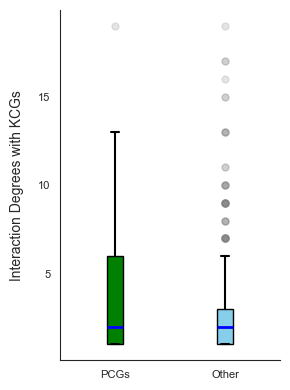

Box plot saved to results/gene_prediction/ACGNN_HIPPIE_degree_distributions_epo50.png


In [250]:
##################################################################
# Rank nodes by scores for only non-labeled nodes
node_names = list(nodes.keys())
non_labeled_nodes = [i for i, label in enumerate(results["labels"]) if label == -1]  # Indices of non-labeled nodes
non_labeled_scores = [(node_names[i],results["scores"][i]) for i in non_labeled_nodes]

ranking = sorted(non_labeled_scores, key=lambda x: x[1], reverse=True)


process_predictions(ranking, args, "data/796_drivers.txt", "data/oncokb_1172.txt", "data/depmap_35331.txt", "data/ncg_8886.txt", "data/intogen_23444.txt", node_names, non_labeled_nodes)

# Load driver and reference gene sets


# Calculate statistics
non_labeled_nodes_count = len(non_labeled_nodes)
ground_truth_driver_nodes = [i for i, label in enumerate(labels) if label == 1]
ground_truth_non_driver_nodes = [i for i, label in enumerate(labels) if label == 0]


# Save both above and below threshold scores, sorted by scores in descending order
predicted_driver_nodes_above_threshold = sorted(
    [(node_names[i], results["scores"][i]) for i in non_labeled_nodes if results["scores"][i] >= args.score_threshold],
    key=lambda x: x[1],
    reverse=True
)
predicted_driver_nodes_below_threshold = sorted(
    [(node_names[i], results["scores"][i]) for i in non_labeled_nodes if results["scores"][i] < args.score_threshold],
    key=lambda x: x[1],
    reverse=True
)

from collections import defaultdict
import statistics

# Get the ground truth driver gene indices and names
ground_truth_driver_indices = [i for i, label in enumerate(results["labels"]) if label == 1]
ground_truth_driver_names = {node_names[i] for i in ground_truth_driver_indices}

# Save predictions (above and below threshold) to CSV
output_file_above = os.path.join(
    'results/gene_prediction/',
    f'{args.model_type}_{args.net_type}_predicted_driver_genes_above_epo{args.num_epochs}.csv'
)
output_file_below = os.path.join(
    'results/gene_prediction/',
    f'{args.model_type}_{args.net_type}_predicted_driver_genes_below_epo{args.num_epochs}.csv'
)

with open(output_file_above, 'w', newline='') as csvfile:
    csvwriter = csv.writer(csvfile)
    csvwriter.writerow(['Gene Name', 'Score'])  # Header row
    csvwriter.writerows(predicted_driver_nodes_above_threshold)

with open(output_file_below, 'w', newline='') as csvfile:
    csvwriter = csv.writer(csvfile)
    csvwriter.writerow(['Gene Name', 'Score'])  # Header row
    csvwriter.writerows(predicted_driver_nodes_below_threshold)

print(f"Predicted driver genes (above threshold) saved to {output_file_above}")
print(f"Predicted driver genes (below threshold) saved to {output_file_below}")

# Calculate degrees for nodes above and below the threshold (connecting only to label 1 nodes)
degree_counts_above = defaultdict(int)
degree_counts_below = defaultdict(int)

for src, dst in edges:
    src_name = node_names[src]
    dst_name = node_names[dst]

    # Count only connections to ground truth driver genes (label 1 nodes)
    if dst_name in ground_truth_driver_names:
        if src_name in [gene for gene, _ in predicted_driver_nodes_above_threshold]:
            degree_counts_above[src_name] += 1
        elif src_name in [gene for gene, _ in predicted_driver_nodes_below_threshold]:
            degree_counts_below[src_name] += 1

# Sort degrees by degree count in descending order
sorted_degree_counts_above = sorted(degree_counts_above.items(), key=lambda x: x[1], reverse=True)
sorted_degree_counts_below = sorted(degree_counts_below.items(), key=lambda x: x[1], reverse=True)

# Save degrees of predicted driver genes connecting to ground truth driver genes (above threshold)
degree_output_file_above = os.path.join(
    'results/gene_prediction/',
    f'{args.model_type}_{args.net_type}_predicted_driver_gene_degrees_above_epo{args.num_epochs}.csv'
)
with open(degree_output_file_above, 'w', newline='') as csvfile:
    csvwriter = csv.writer(csvfile)
    csvwriter.writerow(['Predicted Driver Gene', 'Degree'])  # Header row
    csvwriter.writerows(sorted_degree_counts_above)
    ##csvwriter.writerow(['Average Degree', average_degree_above])  # Save average degree

print(f"Degrees of predicted driver genes (above threshold) saved to {degree_output_file_above}")



# Prepare DataFrame for nodes with degrees
nodes_with_degrees = []

# Above threshold
for gene, degree in degree_counts_above.items():
    nodes_with_degrees.append({'Gene_Set': 'Above Threshold', 'Degree': degree})

# Below threshold
for gene, degree in degree_counts_below.items():
    nodes_with_degrees.append({'Gene_Set': 'Below Threshold', 'Degree': degree})

# Convert to DataFrame
nodes_with_degrees = pd.DataFrame(nodes_with_degrees)

##print(f"sorted_degree_counts_below: {sorted_degree_counts_below}")
sorted_degree_counts_above_value = [value for _, value in sorted_degree_counts_above if value <= 20]
sorted_degree_counts_below_value = [value for _, value in sorted_degree_counts_below if value <= 20]


    

def plot_degree_distributions(sorted_degree_counts_above, sorted_degree_counts_below, args, output_dir):
    """
    Generates a box plot comparing interaction degrees of PCGs vs. Other Genes with KCGs.
    
    Parameters:
    - sorted_degree_counts_above: List of degrees for PCGs.
    - sorted_degree_counts_below: List of degrees for other genes.
    - args: Arguments containing model and training configuration.
    - output_dir: Directory to save the plot.
    """

    print("Generating box plot for degree distributions...")

    degree_data = [sorted_degree_counts_above, sorted_degree_counts_below]

    plt.figure(figsize=(3, 4))

    # Create the box plot
    boxplot = plt.boxplot(
        degree_data,
        vert=True,
        patch_artist=True,  # Allows customization of box color
        flierprops=dict(marker='o', markerfacecolor='grey', markeredgecolor='grey', markersize=5, alpha=0.2),  # Outliers
        boxprops=dict(color='black'),  # Box border color
        medianprops=dict(color='blue', linewidth=2),  # Median line style
        whiskerprops=dict(color='black', linewidth=1.5),  # Whiskers
        capprops=dict(color='black', linewidth=1.5)  # Caps
    )

    # Customize frame
    ax = plt.gca()
    ax.spines['top'].set_visible(False)  # Remove top frame line
    ax.spines['right'].set_visible(False)  # Remove right frame line

    # X-axis labels
    plt.xticks([1, 2], ['PCGs', 'Other'], fontsize=8)  
    plt.yticks(fontsize=8)
    plt.ylabel('Interaction Degrees with KCGs', fontsize=10, labelpad=10) 

    # Assign different colors to box plots
    colors = ['green', 'skyblue']
    for patch, color in zip(boxplot['boxes'], colors):
        patch.set_facecolor(color)

    # Save the plot
    os.makedirs(output_dir, exist_ok=True)
    output_plot_path = os.path.join(output_dir, f'{args.model_type}_{args.net_type}_degree_distributions_epo{args.num_epochs}.png')
    plt.savefig(output_plot_path, bbox_inches='tight')

    plt.tight_layout()
    plt.show()
    print(f"Box plot saved to {output_plot_path}")


plot_degree_distributions(sorted_degree_counts_above_value, sorted_degree_counts_below_value, args, RESULTS_DIR)


Preparing data for KDE plot...
Generating KDE plot...
KDE plot saved to results/gene_prediction/ACGNN_HIPPIE_kde_plot_epo50.png


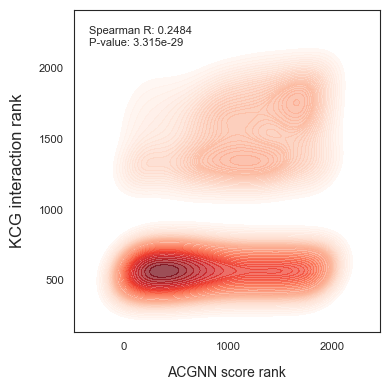

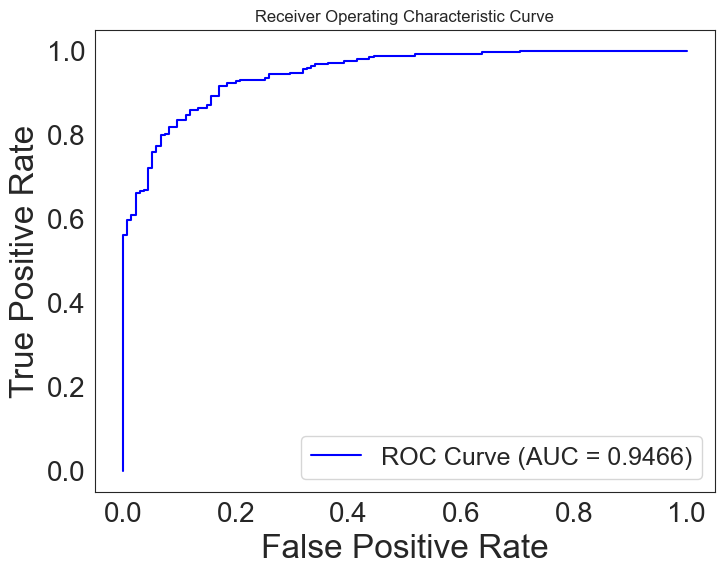

ROC Curve saved to results/gene_prediction/ACGNN_HIPPIE_epo50_roc_curves.png


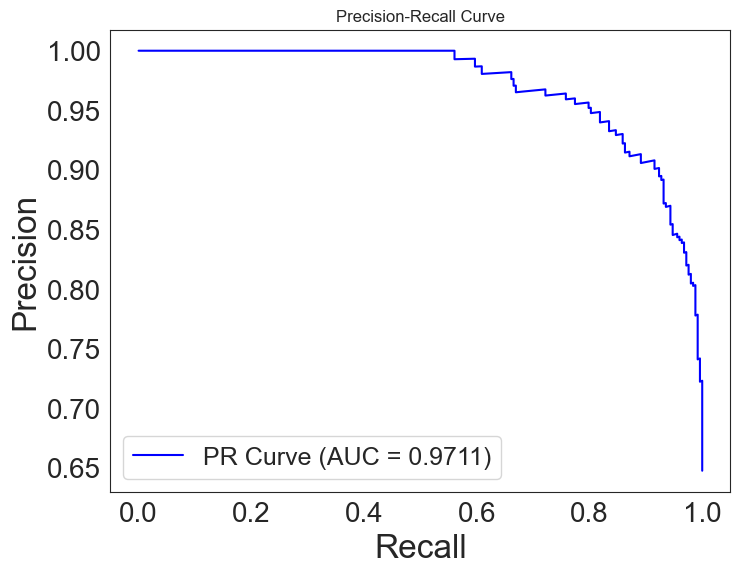

Precision-Recall Curve saved to results/gene_prediction/ACGNN_HIPPIE_epo50_pr_curves.png
ROC curve saved to results/gene_prediction/ACGNN_HIPPIE_epo50_roc_curves.png
PR curve saved to results/gene_prediction/ACGNN_HIPPIE_epo50_pr_curves.png
correlation =  0.2484325870758735


In [251]:

correlation = generate_kde_and_curves(results["logits"], node_names, results["degree_counts_above"], results["degree_counts_below"], results["labels"], results["train_mask"], args)
print('correlation = ', correlation)

In [252]:
print(results["model"])

ACGNN(
  (cheb1): ChebConv(
    (linear): Linear(in_features=6144, out_features=128, bias=True)
  )
  (cheb2): ChebConv(
    (linear): Linear(in_features=384, out_features=128, bias=True)
  )
  (cheb3): ChebConv(
    (linear): Linear(in_features=384, out_features=128, bias=True)
  )
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
  (norm): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout_layer): Dropout(p=0.3, inplace=False)
)


In [253]:

# -------------------------
# Helper: Save model structure
# -------------------------
def save_model_details(model, args, path, in_feats, hidden_feats, out_feats):
    rows = []
    for name, param in model.named_parameters():
        rows.append({
            "parameter": name,
            "shape": list(param.shape),
            "num_params": param.numel()
        })

    df = pd.DataFrame(rows)
    df["in_feats"] = in_feats
    df["hidden_feats"] = hidden_feats
    df["out_feats"] = out_feats
    df["model_type"] = args.model_type

    df.to_csv(path, index=False)
    print(f"[OK] Model structure saved → {path}")


# -------------------------
# Helper: Performance metrics (epoch-level)
# -------------------------
def save_performance_metrics(epoch_times, cpu_usages, gpu_usages, args, output_dir):
    df = pd.DataFrame({
        "epoch": range(1, len(epoch_times) + 1),
        "epoch_time_sec": epoch_times,
        "cpu_usage_percent": cpu_usages,
        "gpu_memory_mb": gpu_usages,
    })

    path = os.path.join(
        output_dir,
        f"{args.model_type}_{args.net_type}_performance_metrics_epo{args.num_epochs}.csv"
    )
    df.to_csv(path, index=False)
    print(f"[OK] Performance metrics saved → {path}")
    return path


# -------------------------
# Helper: Overall metrics
# -------------------------
def save_overall_metrics(total_time, avg_epoch_time, avg_cpu, avg_gpu, args, output_dir):
    df = pd.DataFrame([{
        "model": args.model_type,
        "network": args.net_type,
        "epochs": args.num_epochs,
        "total_time_sec": total_time,
        "avg_epoch_time_sec": avg_epoch_time,
        "avg_cpu_percent": avg_cpu,
        "avg_gpu_mb": avg_gpu
    }])

    path = os.path.join(
        output_dir,
        f"{args.model_type}_{args.net_type}_overall_metrics_epo{args.num_epochs}.csv"
    )
    df.to_csv(path, index=False)
    print(f"[OK] Overall metrics saved → {path}")
    return path


# # -------------------------
# # Helper: Predicted scores for all nodes
# # -------------------------
# def save_predicted_scores(scores, labels, nodes, args, output_dir):
#     node_names = list(nodes.keys())

#     df = pd.DataFrame({
#         "Gene": node_names,
#         "Score": scores,
#         "Label": labels.cpu().numpy()
#     })

#     path = os.path.join(
#         output_dir,
#         f"{args.model_type}_{args.net_type}_all_node_scores_epo{args.num_epochs}.csv"
#     )
#     df.to_csv(path, index=False)
#     print(f"[OK] Node scores saved → {path}")
#     return df


# -------------------------
# Helper: Predicted driver genes
# -------------------------
def save_predicted_driver_genes(node_names, scores, non_labeled_nodes, args, output_dir):
    above = [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] >= args.score_threshold]
    below = [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] < args.score_threshold]

    df_above = pd.DataFrame(above, columns=["Gene", "Score"])
    df_below = pd.DataFrame(below, columns=["Gene", "Score"])

    path_above = os.path.join(
        output_dir,
        f"{args.model_type}_{args.net_type}_predicted_driver_genes_above_epo{args.num_epochs}.csv"
    )
    path_below = os.path.join(
        output_dir,
        f"{args.model_type}_{args.net_type}_predicted_driver_genes_below_epo{args.num_epochs}.csv"
    )

    df_above.to_csv(path_above, index=False)
    df_below.to_csv(path_below, index=False)

    print(f"[OK] Predicted driver genes saved")
    return path_above, path_below, df_above, df_below


# -------------------------
# Helper: Degree CSVs
# -------------------------
def save_degree_csv(degree_counts, args, output_dir, tag):
    df = pd.DataFrame(
        degree_counts.items(),
        columns=["Gene", "Degree"]
    ).sort_values("Degree", ascending=False)

    path = os.path.join(
        output_dir,
        f"{args.model_type}_{args.net_type}_degree_{tag}_epo{args.num_epochs}.csv"
    )

    df.to_csv(path, index=False)
    print(f"[OK] Degree CSV saved → {path}")
    return path

In [254]:
csv_file_path = os.path.join(
        RESULTS_DIR,
        f'{args.model_type}_{args.net_type}_predicted_scores_threshold{args.score_threshold}_epo{args.num_epochs}.csv')


In [255]:


save_performance_metrics(
    results["epoch_times"],
    results["cpu"],
    results["gpu"],
    args,
    RESULTS_DIR
)

save_overall_metrics(
    sum(results["epoch_times"]),
    sum(results["epoch_times"]) / args.num_epochs,
    sum(results["cpu"]) / args.num_epochs,
    sum(results["gpu"]) / args.num_epochs,
    args,
    RESULTS_DIR
)

# csv_file_path = os.path.join(
#         RESULTS_DIR,
#         f'{args.model_type}_{args.net_type}_predicted_scores_threshold{args.score_threshold}_epo{args.num_epochs}.csv')

scores_df = save_predicted_scores(
    results["scores"],
    results["labels"],
    results["nodes"],
    args,
    csv_file_path
)

# save_predicted_scores(scores, labels, nodes, args)

node_names = list(results["nodes"].keys())
labels_np = results["labels"].numpy()

non_labeled_nodes = [i for i, l in enumerate(labels_np) if l == -1]

predicted_above = [
    (node_names[i], results["scores"][i])
    for i in non_labeled_nodes
    if results["scores"][i] >= args.score_threshold
]

predicted_below = [
    (node_names[i], results["scores"][i])
    for i in non_labeled_nodes
    if results["scores"][i] < args.score_threshold
]

df_above = pd.DataFrame(predicted_above, columns=["Gene", "Score"])
df_below = pd.DataFrame(predicted_below, columns=["Gene", "Score"])

df_above.to_csv(
    f"{RESULTS_DIR}/{args.model_type}_{args.net_type}_predicted_driver_genes_above_epo{args.num_epochs}.csv",
    index=False
)
df_below.to_csv(
    f"{RESULTS_DIR}/{args.model_type}_{args.net_type}_predicted_driver_genes_below_epo{args.num_epochs}.csv",
    index=False
)



[OK] Performance metrics saved → results/gene_prediction/ACGNN_HIPPIE_performance_metrics_epo50.csv
[OK] Overall metrics saved → results/gene_prediction/ACGNN_HIPPIE_overall_metrics_epo50.csv
Predicted scores and labels saved to results/gene_prediction/ACGNN_HIPPIE_predicted_scores_threshold0.99_epo50.csv


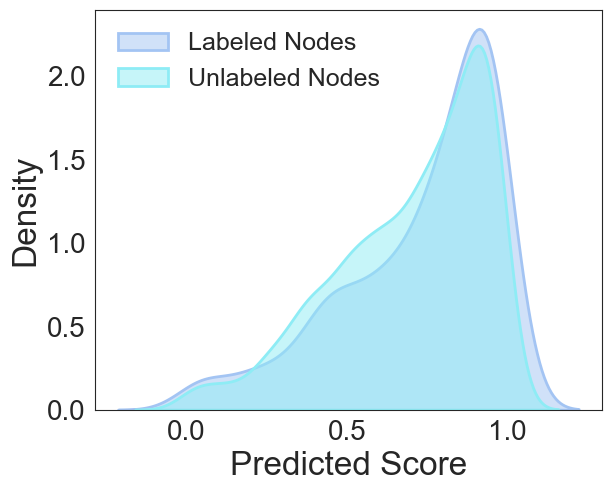

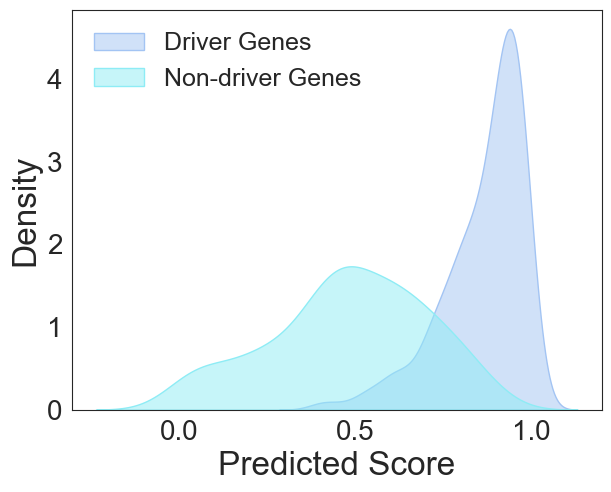

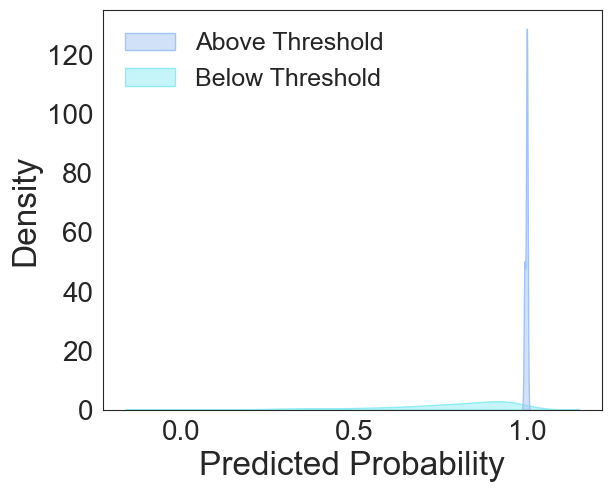

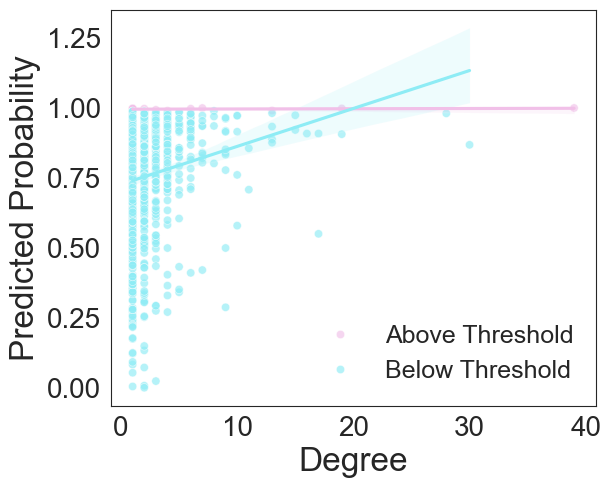

In [256]:
GROUP_COLORS = {
    "Above Threshold": "#a3c4f3",
    "Below Threshold": "#b9fbc0"
}


# def generate_score_distr(
#     scores,                # ← probabilities, NOT raw logits
#     logits,
#     node_names,
#     degree_counts_above,
#     degree_counts_below,
#     labels,
#     train_mask,
#     args
# ):
#     import pandas as pd
#     import numpy as np
#     import matplotlib.pyplot as plt
#     import seaborn as sns

#     plt.rcParams.update({
#         "axes.labelsize": 16,
#         "xtick.labelsize": 14,
#         "ytick.labelsize": 14,
#         "legend.fontsize": 13
#     })

#     # ----------------------------
#     # Prepare scores
#     # ----------------------------
#     scores = torch.sigmoid(logits).detach().cpu().numpy()
#     labels_np = labels.detach().cpu().numpy()
#     train_mask_np = train_mask.detach().cpu().numpy()

#     # ----------------------------
#     # Separate node groups
#     # ----------------------------
#     labeled_scores = scores[train_mask_np]
#     unlabeled_scores = scores[~train_mask_np]

#     driver_scores = scores[labels_np == 1]
#     non_driver_scores = scores[labels_np == 0]

#     plt.figure(figsize=(6, 4))

#     sns.kdeplot(
#         labeled_scores,
#         label="Labeled Nodes",
#         fill=True,
#         alpha=0.4,
#         linewidth=2
#     )

#     sns.kdeplot(
#         unlabeled_scores,
#         label="Unlabeled Nodes",
#         fill=True,
#         alpha=0.4,
#         linewidth=2
#     )

#     plt.xlabel("Predicted Score")
#     plt.ylabel("Density")
#     plt.legend(frameon=False)
#     plt.tight_layout()

#     plt.savefig(
#         os.path.join(
#             RESULTS_DIR,
#             f"{args.model_type}_{args.net_type}_kde_labeled_vs_unlabeled.png"
#         ),
#         dpi=300
#     )
#     plt.show()


#     # ----------------------------
#     # KDE plot: driver vs non-driver (FILLED)
#     # ----------------------------
#     plt.figure(figsize=(6, 4))

#     sns.kdeplot(
#         driver_scores,
#         label="Driver Genes",
#         fill=True,
#         alpha=0.4,
#         # linewidth=2
#         common_norm=False
#     )

#     sns.kdeplot(
#         non_driver_scores,
#         label="Non-driver Genes",
#         fill=True,
#         alpha=0.4,
#         # linewidth=2,
#         common_norm=False
#     )

#     plt.xlabel("Predicted Score")
#     plt.ylabel("Density")
#     plt.legend(frameon=False)
#     plt.tight_layout()

#     plt.savefig(
#         os.path.join(
#             RESULTS_DIR,
#             f"{args.model_type}_{args.net_type}_kde_driver_vs_nondriver.png"
#         ),
#         dpi=300
#     )
#     plt.show()

#     # -----------------------------
#     # Build score lookup
#     # -----------------------------
#     scores = np.asarray(scores).reshape(-1)
#     assert len(scores) == len(node_names), "scores / node_names mismatch"

#     score_map = dict(zip(node_names, scores))

#     # -----------------------------
#     # Build DEGREE dataframe (ONE source of truth)
#     # -----------------------------
#     rows = []

#     for gene, deg in degree_counts_above.items():
#         rows.append({
#             "Gene": gene,
#             "Degree": deg,
#             "Group": "Above Threshold",
#             "Score": score_map.get(gene, np.nan)
#         })

#     for gene, deg in degree_counts_below.items():
#         rows.append({
#             "Gene": gene,
#             "Degree": deg,
#             "Group": "Below Threshold",
#             "Score": score_map.get(gene, np.nan)
#         })

#     degree_df = pd.DataFrame(rows)

#     # -----------------------------
#     # HARD VALIDATION (NO SILENCE)
#     # -----------------------------
#     print("Columns:", degree_df.columns.tolist())
#     print(degree_df.head())

#     assert "Score" in degree_df.columns
#     assert "Degree" in degree_df.columns
#     assert degree_df["Score"].notna().any(), "All Score values are NaN"

#     # -----------------------------
#     # KDE plot
#     # -----------------------------plt.figure(figsize=(6, 4))

#     ax = sns.kdeplot(
#         data=degree_df.dropna(subset=["Score"]),
#         x="Score",
#         hue="Group",
#         fill=True,
#         alpha=0.4,
#         common_norm=False
#     )

#     plt.xlabel("Predicted Probability", fontsize=16)
#     plt.ylabel("Density", fontsize=16)

#     plt.xticks(fontsize=14)
#     plt.yticks(fontsize=14)

#     # ---- Remove legend title ("Group") ----
#     legend = ax.get_legend()
#     if legend is not None:
#         legend.set_title("")   # removes "Group"
#         legend.set_frame_on(False)

#     plt.tight_layout()
#     plt.show()


#     # -----------------------------
#     # Degree vs Score
#     # -----------------------------
#     plt.figure(figsize=(6, 4))

#     sns.scatterplot(
#         data=degree_df,
#         x="Degree",
#         y="Score",
#         hue="Group",
#         alpha=0.6
#     )

#     sns.regplot(
#         data=degree_df.query("Group == 'Above Threshold'"),
#         x="Degree",
#         y="Score",
#         scatter=False,
#         # label="Above Threshold"
#     )

#     sns.regplot(
#         data=degree_df.query("Group == 'Below Threshold'"),
#         x="Degree",
#         y="Score",
#         scatter=False,
#         # label="Below Threshold"
#     )

#     plt.xlabel("Degree (connections to known drivers)", fontsize=16)
#     plt.ylabel("Predicted Probability", fontsize=16)

#     plt.xticks(fontsize=14)
#     plt.yticks(fontsize=14)

#     plt.legend(
#         fontsize=13,
#         frameon=False
#     )

#     plt.tight_layout()
#     plt.show()

def generate_score_distr(
    scores,                # ← probabilities, NOT raw logits (kept for API consistency)
    logits,
    node_names,
    degree_counts_above,
    degree_counts_below,
    labels,
    train_mask,
    args
):
    import os
    import torch
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # ----------------------------
    # Defined colors (GLOBAL)
    # ----------------------------
    colors = ['#a3c4f3', '#8eecf5']  # light blue, cyan

    sns.set_style("white")
    plt.rcParams.update({
        "axes.labelsize": 24,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "legend.fontsize": 18
    })

    # ----------------------------
    # Prepare scores
    # ----------------------------
    scores = torch.sigmoid(logits).detach().cpu().numpy()
    labels_np = labels.detach().cpu().numpy()
    train_mask_np = train_mask.detach().cpu().numpy()

    # ----------------------------
    # Separate node groups
    # ----------------------------
    labeled_scores = scores[train_mask_np]
    unlabeled_scores = scores[~train_mask_np]

    driver_scores = scores[labels_np == 1]
    non_driver_scores = scores[labels_np == 0]

    # ==========================================================
    # KDE: Labeled vs Unlabeled
    # ==========================================================
    plt.figure(figsize=(6, 5))

    sns.kdeplot(
        labeled_scores,
        label="Labeled Nodes",
        fill=True,
        alpha=0.5,
        linewidth=2,
        color=colors[0]
    )

    sns.kdeplot(
        unlabeled_scores,
        label="Unlabeled Nodes",
        fill=True,
        alpha=0.5,
        linewidth=2,
        color=colors[1]
    )

    plt.xlabel("Predicted Score")
    plt.ylabel("Density")
    plt.legend(frameon=False)

    plt.tight_layout(pad=0.3)
    plt.subplots_adjust(top=0.95, bottom=0.15)

    plt.savefig(
        os.path.join(
            RESULTS_DIR,
            f"{args.model_type}_{args.net_type}_kde_labeled_vs_unlabeled.png"
        ),
        dpi=300
    )
    plt.show()

    # ==========================================================
    # KDE: Driver vs Non-driver
    # ==========================================================
    plt.figure(figsize=(6, 5))

    sns.kdeplot(
        driver_scores,
        label="Driver Genes",
        fill=True,
        alpha=0.5,
        common_norm=False,
        color=colors[0]
    )

    sns.kdeplot(
        non_driver_scores,
        label="Non-driver Genes",
        fill=True,
        alpha=0.5,
        common_norm=False,
        color=colors[1]
    )

    plt.xlabel("Predicted Score")
    plt.ylabel("Density")
    plt.legend(frameon=False)

    plt.tight_layout(pad=0.3)
    plt.subplots_adjust(top=0.95, bottom=0.15)

    plt.savefig(
        os.path.join(
            RESULTS_DIR,
            f"{args.model_type}_{args.net_type}_kde_driver_vs_nondriver.png"
        ),
        dpi=300
    )
    plt.show()

    # ==========================================================
    # Build score lookup
    # ==========================================================
    scores = np.asarray(scores).reshape(-1)
    assert len(scores) == len(node_names), "scores / node_names mismatch"
    score_map = dict(zip(node_names, scores))

    # ==========================================================
    # Degree dataframe
    # ==========================================================
    rows = []

    for gene, deg in degree_counts_above.items():
        rows.append({
            "Gene": gene,
            "Degree": deg,
            "Group": "Above Threshold",
            "Score": score_map.get(gene, np.nan)
        })

    for gene, deg in degree_counts_below.items():
        rows.append({
            "Gene": gene,
            "Degree": deg,
            "Group": "Below Threshold",
            "Score": score_map.get(gene, np.nan)
        })

    degree_df = pd.DataFrame(rows)

    assert degree_df["Score"].notna().any(), "All Score values are NaN"

    # ==========================================================
    # KDE: Degree groups
    # ==========================================================
    plt.figure(figsize=(6, 5))

    ax = sns.kdeplot(
        data=degree_df.dropna(subset=["Score"]),
        x="Score",
        hue="Group",
        fill=True,
        alpha=0.5,
        common_norm=False,
        palette=colors
    )

    plt.xlabel("Predicted Probability")
    plt.ylabel("Density")

    legend = ax.get_legend()
    if legend is not None:
        legend.set_title("")
        legend.set_frame_on(False)

    plt.tight_layout(pad=0.3)
    plt.subplots_adjust(top=0.95, bottom=0.15)

    plt.savefig(
        os.path.join(
            RESULTS_DIR,
            f"{args.model_type}_{args.net_type}_kde_degree_groups.png"
        ),
        dpi=300
    )
    plt.show()

    # ==========================================================
    # Scatter: Degree vs Score
    # ==========================================================
    
    colors = ['#f1c0e8', '#8eecf5']
    
    plt.figure(figsize=(6, 4.95))

    sns.scatterplot(
        data=degree_df,
        x="Degree",
        y="Score",
        hue="Group",
        alpha=0.65,
        palette=colors
    )

    sns.regplot(
        data=degree_df.query("Group == 'Above Threshold'"),
        x="Degree",
        y="Score",
        scatter=False,
        color=colors[0]
    )

    sns.regplot(
        data=degree_df.query("Group == 'Below Threshold'"),
        x="Degree",
        y="Score",
        scatter=False,
        color=colors[1]
    )

    plt.xlabel("Degree")
    plt.ylabel("Predicted Probability")

    plt.legend(frameon=False)

    plt.tight_layout(pad=0.3)
    plt.subplots_adjust(top=0.95, bottom=0.15)

    plt.savefig(
        os.path.join(
            RESULTS_DIR,
            f"{args.model_type}_{args.net_type}_degree_vs_score.png"
        ),
        dpi=300
    )
    plt.show()


generate_score_distr(
    scores=results["scores"],
    logits=results["logits"],
    node_names=list(results["nodes"].keys()),
    degree_counts_above=results["degree_counts_above"],
    degree_counts_below=results["degree_counts_below"],
    labels=results["labels"],
    train_mask=results["train_mask"],
    args=args
)

In [257]:
metrics_csv_path = os.path.join(
        'results/gene_prediction/',
        f'{args.model_type}_{args.net_type}_performance_metrics_epo{args.num_epochs}.csv'
    )

In [258]:
score_file = os.path.join(
        'results/gene_prediction/',
        f'{args.model_type}_{args.net_type}_predicted_scores_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )

In [259]:
metrics_csv_path = os.path.join(
    "results/gene_prediction",
    f"{args.model_type}_{args.net_type}_performance_metrics_epo{args.num_epochs}.csv"
)

In [260]:
metrics_df = pd.read_csv(metrics_csv_path)
metrics_df.head()



,epoch,epoch_time_sec,cpu_usage_percent,gpu_memory_mb
0,1,0.236209,15.3,0.0
1,2,0.139366,46.1,0.0
2,3,0.136857,54.5,0.0
3,4,0.138950,53.8,0.0
4,5,0.140096,54.2,0.0


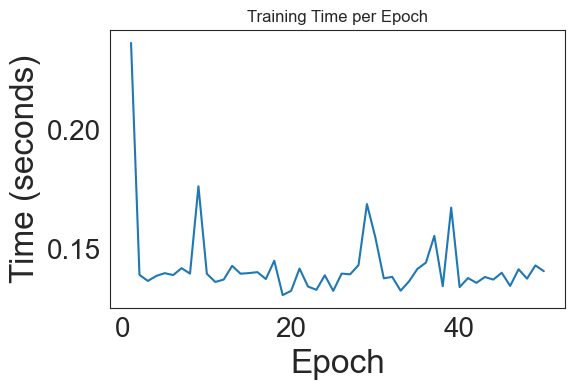

In [261]:
# 
plt.figure(figsize=(6, 4))

# plt.plot(metrics_df["Epoch"], metrics_df["Time per Epoch (s)"], marker="o")

plt.plot(metrics_df["epoch"], metrics_df["epoch_time_sec"], marker="")

plt.xlabel("Epoch")
plt.ylabel("Time (seconds)")
plt.title("Training Time per Epoch")
# plt.grid(False, alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(RESULTS_DIR, "epoch_time.png"), dpi=300)
plt.show()

In [262]:

# 

scores_df = pd.read_csv(score_file)
scores_df.head()


,Node Name,Score,Label
0,DLG4,0.987950,3
1,ERBB2,0.923151,1
2,MMP7,0.806293,1
3,CD44,0.801729,3
4,TLE1,0.841770,3


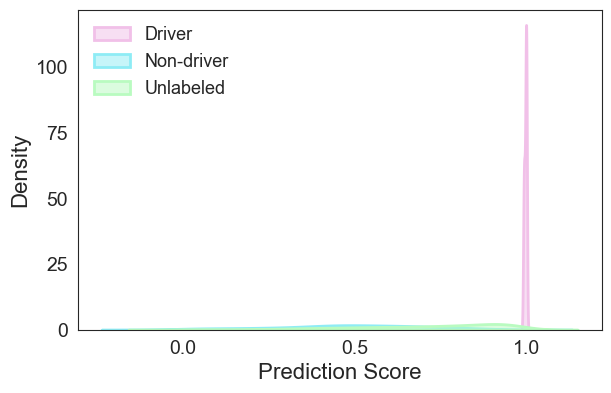

In [263]:

# 

# label_map = {
#     2: "Driver",
#     0: "Non-driver",
#     3: "Unlabeled"
# }

# plt.figure(figsize=(6, 4))

# for lbl, name in label_map.items():
#     sns.kdeplot(
#         scores_df[scores_df["Label"] == lbl]["Score"],
#         label=name,
#         fill=True
#     )

# plt.xlabel("Prediction Score")
# plt.ylabel("Density")
# plt.legend()
# plt.tight_layout()

# plt.savefig(os.path.join(RESULTS_DIR, "score_distribution.png"), dpi=300)
# plt.show()

# ---- Defined colors (fixed palette) ----
colors = ['#f1c0e8', '#8eecf5', '#b9fbc0']  

label_map = {
    2: "Driver",
    0: "Non-driver",
    3: "Unlabeled"
}

# Explicit color assignment per label
label_color_map = {
    2: colors[0],  # Driver
    0: colors[1],  # Non-driver
    3: colors[2]   # Unlabeled (neutral gray to avoid confusion)
}

plt.figure(figsize=(6, 4))

for lbl, name in label_map.items():
    sns.kdeplot(
        scores_df[scores_df["Label"] == lbl]["Score"],
        label=name,
        fill=True,
        alpha=0.5,
        linewidth=2,
        color=label_color_map[lbl]
    )

plt.xlabel("Prediction Score", fontsize=16)
plt.ylabel("Density", fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(frameon=False, fontsize=13)

plt.tight_layout(pad=0.3)
plt.subplots_adjust(top=0.95, bottom=0.15)

plt.savefig(
    os.path.join(RESULTS_DIR, "score_distribution.png"),
    dpi=300
)
plt.show()


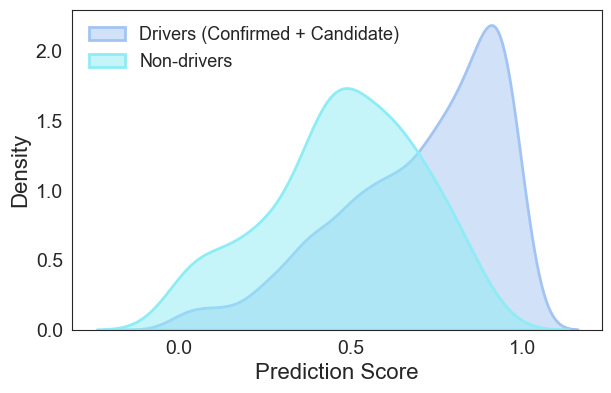

In [264]:
# 
# plt.figure(figsize=(6, 4))

# sns.kdeplot(
#     scores_df[scores_df["Label"].isin([2, 3])]["Score"],
#     label="Drivers (Confirmed + Candidate)",
#     fill=True
# )

# sns.kdeplot(
#     scores_df[scores_df["Label"] == 0]["Score"],
#     label="Non-drivers",
#     fill=True
# )

# plt.xlabel("Prediction Score")
# plt.ylabel("Density")
# plt.legend()
# plt.tight_layout()

# plt.savefig(os.path.join(RESULTS_DIR, "kde_drivers_vs_nondrivers.png"), dpi=300)
# plt.show()

colors = ['#a3c4f3', '#8eecf5']

plt.figure(figsize=(6, 4))

sns.kdeplot(
    scores_df[scores_df["Label"].isin([2, 3])]["Score"],
    label="Drivers (Confirmed + Candidate)",
    fill=True,
    alpha=0.5,
    linewidth=2,
    color=colors[0]
)

sns.kdeplot(
    scores_df[scores_df["Label"] == 0]["Score"],
    label="Non-drivers",
    fill=True,
    alpha=0.5,
    linewidth=2,
    color=colors[1]
)

plt.xlabel("Prediction Score", fontsize=16)
plt.ylabel("Density", fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(frameon=False, fontsize=13)

plt.tight_layout(pad=0.3)
plt.subplots_adjust(top=0.95, bottom=0.15)

plt.savefig(
    os.path.join(RESULTS_DIR, "kde_drivers_vs_nondrivers.png"),
    dpi=300
)
plt.show()


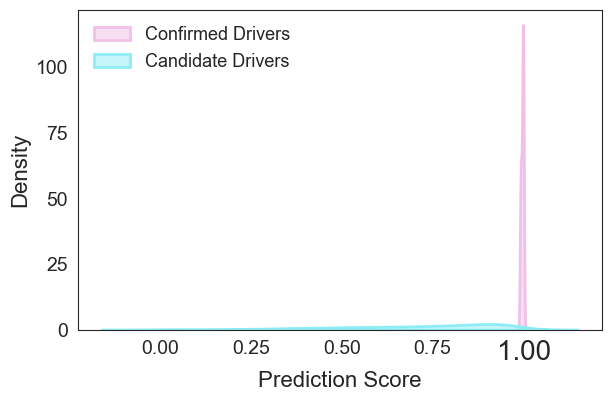

In [265]:
# ---- Defined colors ----
colors = ['#f1c0e8', '#8eecf5']  # confirmed, candidate

plt.figure(figsize=(6, 4))

sns.kdeplot(
    scores_df[scores_df["Label"] == 2]["Score"],
    label="Confirmed Drivers",
    fill=True,
    alpha=0.5,
    linewidth=2,
    color=colors[0]
)

sns.kdeplot(
    scores_df[scores_df["Label"] == 3]["Score"],
    label="Candidate Drivers",
    fill=True,
    alpha=0.5,
    linewidth=2,
    color=colors[1]
)

plt.xlabel("Prediction Score", fontsize=16)
plt.ylabel("Density", fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(frameon=False, fontsize=13)

plt.tight_layout(pad=0.3)
plt.subplots_adjust(top=0.95, bottom=0.15)

plt.savefig(
    os.path.join(RESULTS_DIR, "kde_confirmed_vs_candidates.png"),
    dpi=300
)
plt.show()

 
# plt.figure(figsize=(6, 4))

# sns.kdeplot(
#     scores_df[scores_df["Label"] == 2]["Score"],
#     label="Confirmed Drivers",
#     fill=True
# )

# sns.kdeplot(
#     scores_df[scores_df["Label"] == 3]["Score"],
#     label="Candidate Drivers",
#     fill=True
# )

# plt.xlabel("Prediction Score")
# plt.ylabel("Density")
# plt.legend()
# plt.tight_layout()

# plt.savefig(os.path.join(RESULTS_DIR, "kde_confirmed_vs_candidates.png"), dpi=300)
# plt.show()